  CodeAlpha — TASK 4: Disease Prediction

EDA — Diabetes
                    mean     std    min     max
Pregnancies         3.85    3.37   0.00   17.00
Glucose           121.69   30.54  44.00  199.00
BloodPressure      72.41   12.38  24.00  122.00
SkinThickness      29.15   10.48   7.00   99.00
Insulin           155.55  118.78  14.00  846.00
BMI                32.46    6.92  18.20   67.10
DiabetesPedigree    0.47    0.33   0.08    2.42
Age                33.24   11.76  21.00   81.00
Outcome             0.35    0.48   0.00    1.00

Missing values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64


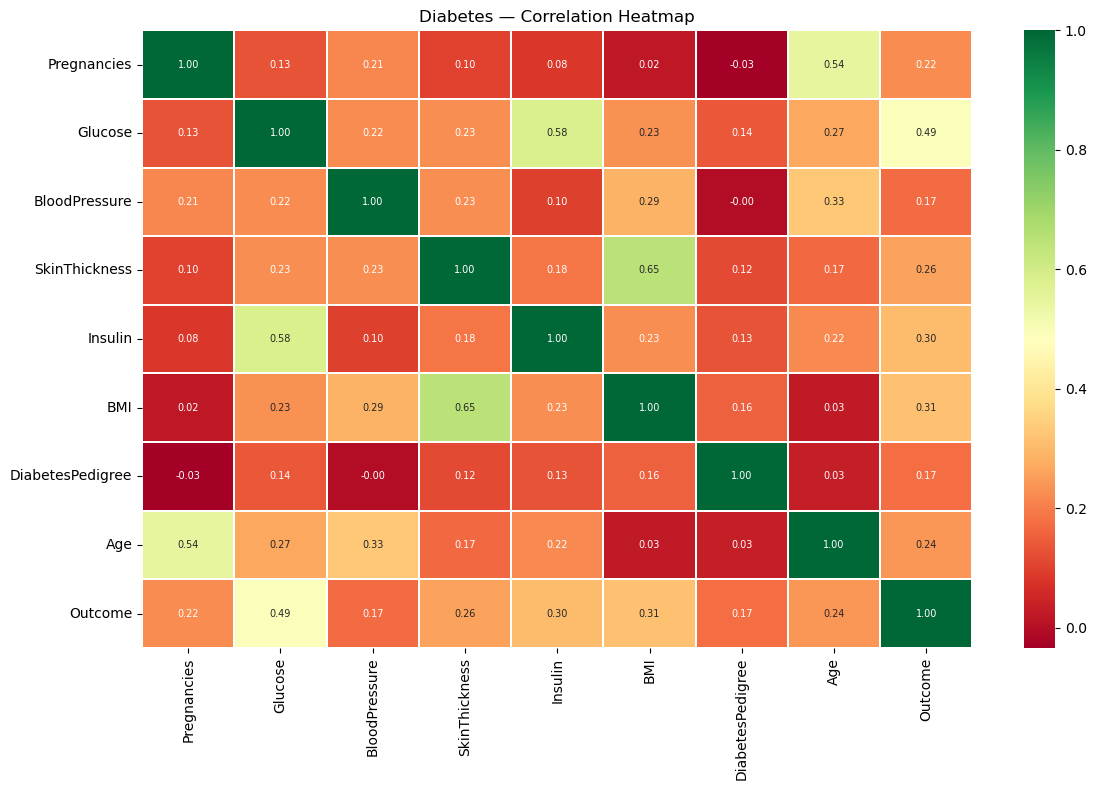


───────────────────────────────────────────────────────
Training on: Diabetes  |  Train=614, Test=154
  Logistic Regression    | Acc=0.7078 | F1=0.7008 | AUC=0.8130
  SVM                    | Acc=0.7403 | F1=0.7349 | AUC=0.7964
  Random Forest          | Acc=0.7468 | F1=0.7423 | AUC=0.8165
  Gradient Boosting      | Acc=0.7662 | F1=0.7628 | AUC=0.8296


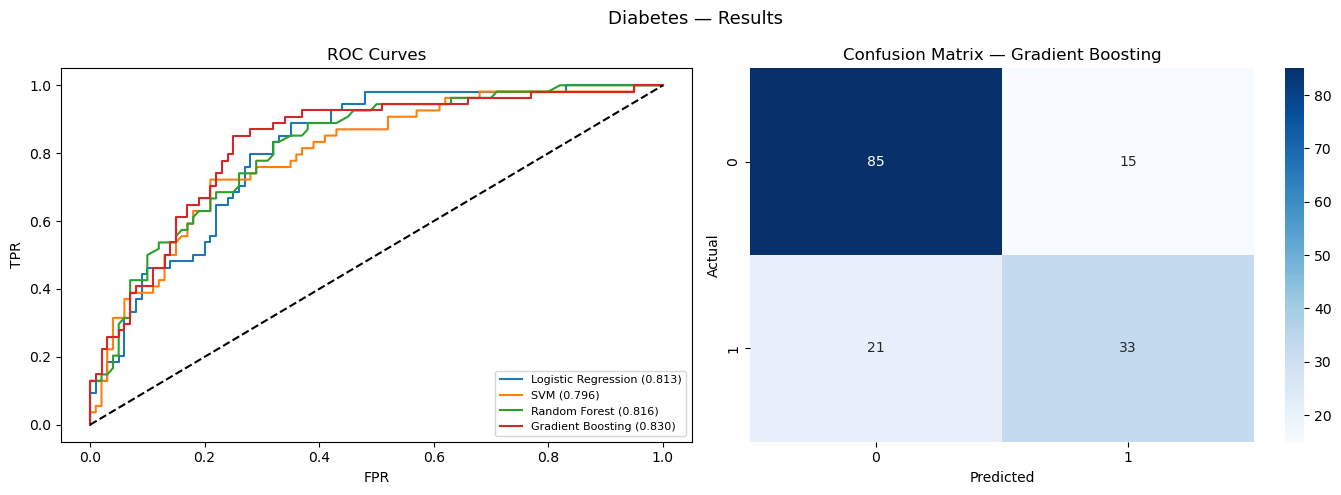


  ✅ Best: Gradient Boosting (AUC=0.8296)

EDA — Breast Cancer
                           mean     std     min      max
mean radius               14.13    3.52    6.98    28.11
mean texture              19.29    4.30    9.71    39.28
mean perimeter            91.97   24.30   43.79   188.50
mean area                654.89  351.91  143.50  2501.00
mean smoothness            0.10    0.01    0.05     0.16
mean compactness           0.10    0.05    0.02     0.35
mean concavity             0.09    0.08    0.00     0.43
mean concave points        0.05    0.04    0.00     0.20
mean symmetry              0.18    0.03    0.11     0.30
mean fractal dimension     0.06    0.01    0.05     0.10
radius error               0.41    0.28    0.11     2.87
texture error              1.22    0.55    0.36     4.88
perimeter error            2.87    2.02    0.76    21.98
area error                40.34   45.49    6.80   542.20
smoothness error           0.01    0.00    0.00     0.03
compactness error        

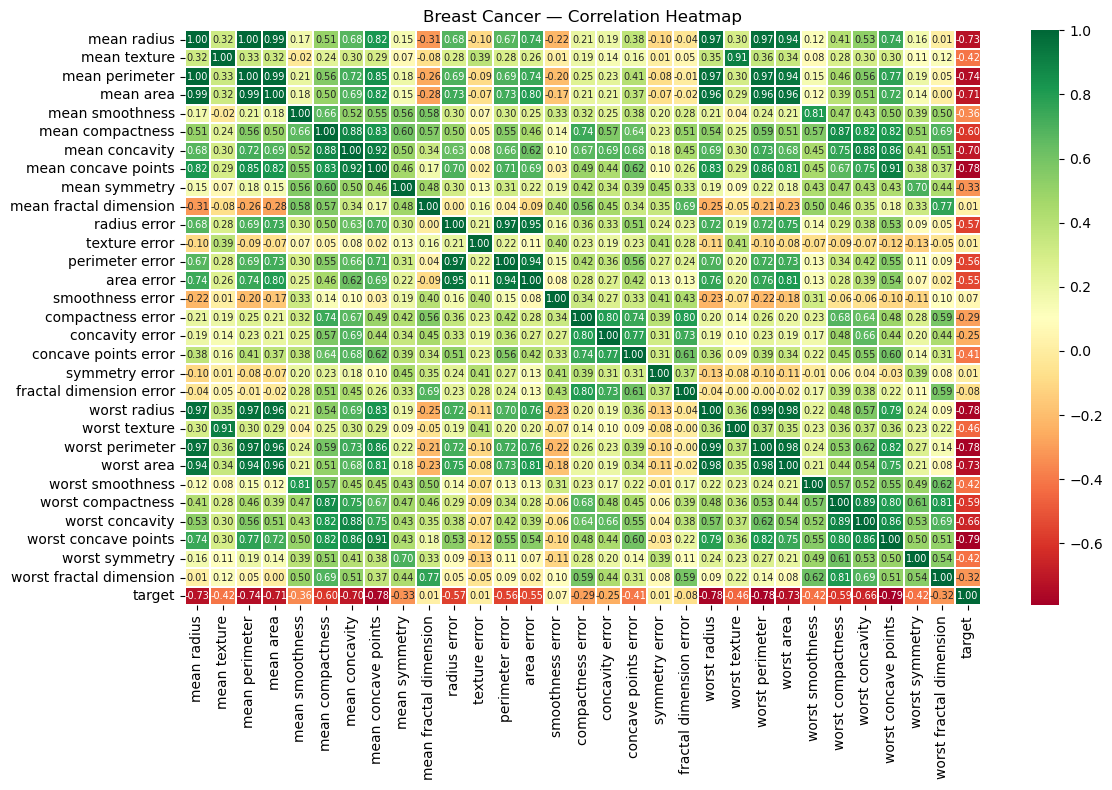


───────────────────────────────────────────────────────
Training on: Breast Cancer  |  Train=455, Test=114
  Logistic Regression    | Acc=0.9825 | F1=0.9825 | AUC=0.9954
  SVM                    | Acc=0.9825 | F1=0.9825 | AUC=0.9950
  Random Forest          | Acc=0.9561 | F1=0.9560 | AUC=0.9932
  Gradient Boosting      | Acc=0.9561 | F1=0.9558 | AUC=0.9911


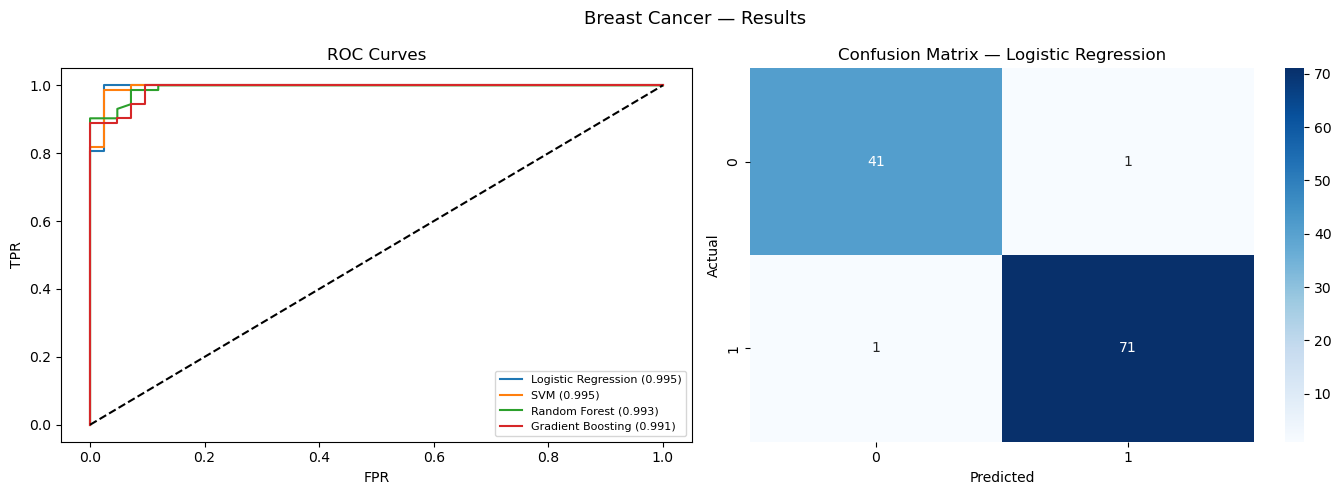


  ✅ Best: Logistic Regression (AUC=0.9954)

EDA — Heart Disease
            mean    std    min    max
age        54.44   9.04   29.0   77.0
sex         0.68   0.47    0.0    1.0
cp          3.16   0.96    1.0    4.0
trestbps  131.69  17.60   94.0  200.0
chol      246.69  51.78  126.0  564.0
fbs         0.15   0.36    0.0    1.0
restecg     0.99   0.99    0.0    2.0
thalach   149.61  22.88   71.0  202.0
exang       0.33   0.47    0.0    1.0
oldpeak     1.04   1.16    0.0    6.2
slope       1.60   0.62    1.0    3.0
ca          0.67   0.94    0.0    3.0
thal        4.73   1.94    3.0    7.0
target      0.46   0.50    0.0    1.0

Missing values:
ca      4
thal    2
dtype: int64

Class balance:
target
0    164
1    139
Name: count, dtype: int64


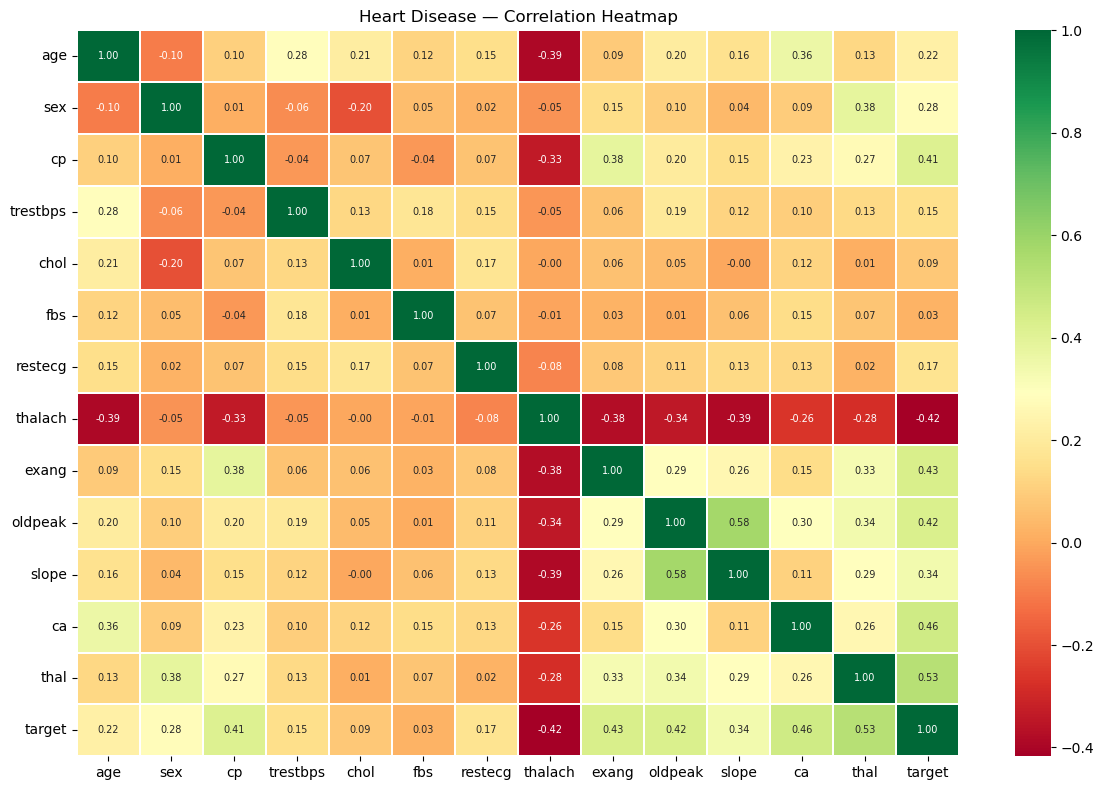


───────────────────────────────────────────────────────
Training on: Heart Disease  |  Train=242, Test=61
  Logistic Regression    | Acc=0.8689 | F1=0.8690 | AUC=0.9513
  SVM                    | Acc=0.8525 | F1=0.8527 | AUC=0.9437
  Random Forest          | Acc=0.9016 | F1=0.9017 | AUC=0.9551
  Gradient Boosting      | Acc=0.8525 | F1=0.8525 | AUC=0.9481


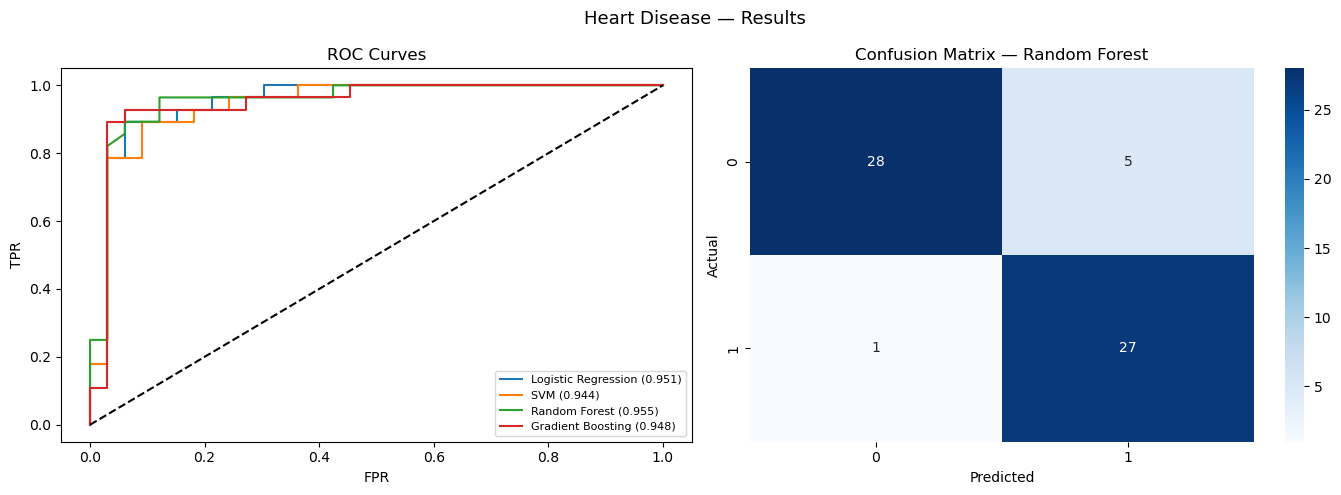


  ✅ Best: Random Forest (AUC=0.9551)

SUMMARY — All Diseases × All Models
Disease              Breast Cancer  Diabetes  Heart Disease
Model                                                      
Gradient Boosting           0.9911    0.8296         0.9481
Logistic Regression         0.9954    0.8130         0.9513
Random Forest               0.9932    0.8165         0.9551
SVM                         0.9950    0.7964         0.9437


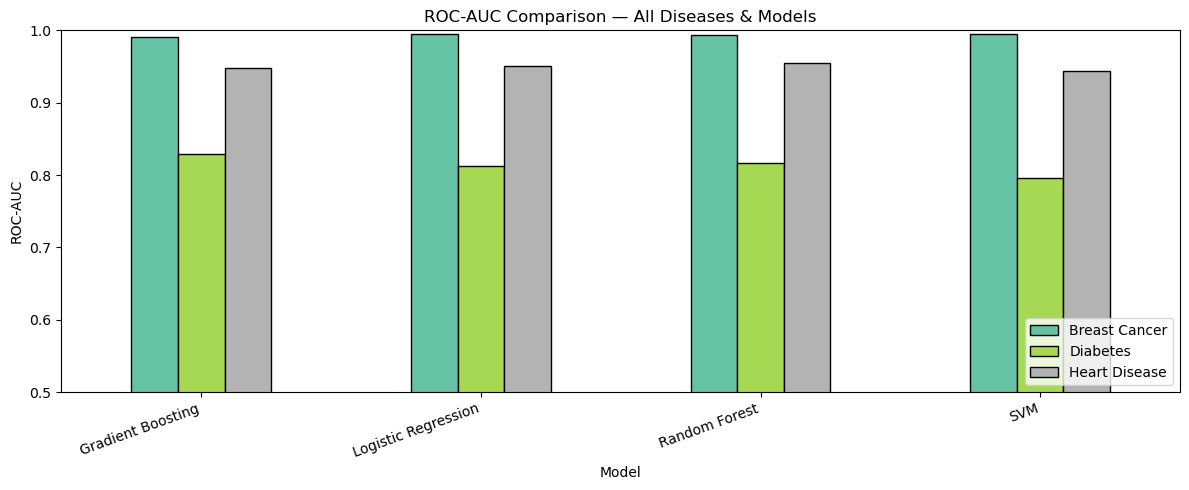


[Summary] Dashboard saved.

✅ All outputs saved. Upload to GitHub as: CodeAlpha_DiseasePrediction


In [2]:
"""
CodeAlpha Internship — Task 4: Disease Prediction from Medical Data
Author: [Your Name]
Description: Predicts disease likelihood from patient data using multiple classifiers.
Datasets: Pima Indians Diabetes, Heart Disease (UCI), Breast Cancer (sklearn built-in)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
# DATASET LOADERS
# ─────────────────────────────────────────────

def load_diabetes():
    """Pima Indians Diabetes Dataset — from local CSV or URL."""
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigree','Age','Outcome']
    try:
        df = pd.read_csv(url, header=None, names=cols)
    except Exception:
        # Fallback: generate synthetic version
        np.random.seed(0)
        n = 768
        df = pd.DataFrame({
            'Pregnancies':       np.random.randint(0,17,n),
            'Glucose':           np.random.normal(120,30,n).clip(44,199),
            'BloodPressure':     np.random.normal(70,12,n).clip(24,122),
            'SkinThickness':     np.random.normal(20,16,n).clip(0,99),
            'Insulin':           np.random.normal(80,115,n).clip(0,846),
            'BMI':               np.random.normal(32,7,n).clip(0,67),
            'DiabetesPedigree':  np.random.uniform(0.08,2.42,n),
            'Age':               np.random.randint(21,81,n),
        })
        score = 0.4*(df['Glucose']/200) + 0.3*(df['BMI']/67) + 0.3*(df['Age']/81)
        df['Outcome'] = (score > score.mean()).astype(int)
    # Replace zero zeros with NaN for biological features
    zero_invalid = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
    df[zero_invalid] = df[zero_invalid].replace(0, np.nan)
    return df, 'Outcome', 'Diabetes'


def load_breast_cancer_data():
    """Breast Cancer Wisconsin Dataset (sklearn built-in)."""
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target  # 0=malignant, 1=benign
    return df, 'target', 'Breast Cancer'


def load_heart_disease():
    """
    Cleveland Heart Disease Dataset (UCI).
    Replace URL with local path if offline.
    """
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','target']
    try:
        df = pd.read_csv(url, header=None, names=cols, na_values='?')
        df['target'] = (df['target'] > 0).astype(int)
    except Exception:
        np.random.seed(1)
        n = 303
        df = pd.DataFrame({
            'age':      np.random.randint(29,77,n),
            'sex':      np.random.randint(0,2,n),
            'cp':       np.random.randint(1,5,n),
            'trestbps': np.random.normal(131,17,n).clip(94,200),
            'chol':     np.random.normal(246,51,n).clip(126,564),
            'fbs':      np.random.randint(0,2,n),
            'restecg':  np.random.randint(0,3,n),
            'thalach':  np.random.normal(149,22,n).clip(71,202),
            'exang':    np.random.randint(0,2,n),
            'oldpeak':  np.random.uniform(0,6.2,n).round(1),
            'slope':    np.random.randint(1,4,n),
            'ca':       np.random.randint(0,4,n),
            'thal':     np.random.choice([3,6,7],n),
        })
        score = 0.4*(df['age']/77) + 0.3*(df['chol']/564) - 0.3*(df['thalach']/202)
        df['target'] = (score > score.mean()).astype(int)
    return df, 'target', 'Heart Disease'


# ─────────────────────────────────────────────
# EDA
# ─────────────────────────────────────────────
def eda(df, target_col, disease_name):
    print(f"\n{'='*55}")
    print(f"EDA — {disease_name}")
    print(f"{'='*55}")
    print(df.describe().T[['mean','std','min','max']].round(2))
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
    print(f"\nClass balance:\n{df[target_col].value_counts()}")

    # Correlation heatmap (only numeric, limit cols)
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
                linewidths=0.3, annot_kws={'size': 7})
    plt.title(f'{disease_name} — Correlation Heatmap')
    plt.tight_layout()
    fname = disease_name.replace(' ', '_').lower()
    plt.savefig(f'eda_{fname}.png', dpi=150)
    plt.show()
    plt.close()


# ─────────────────────────────────────────────
# TRAIN / EVALUATE
# ─────────────────────────────────────────────
def build_pipeline(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     clf)
    ])


MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM':                 SVC(kernel='rbf', probability=True, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
}


def train_dataset(df, target_col, disease_name):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n{'─'*55}")
    print(f"Training on: {disease_name}  |  Train={len(X_train)}, Test={len(X_test)}")

    results = {}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{disease_name} — Results', fontsize=13)

    for name, clf in MODELS.items():
        pipe = build_pipeline(clf)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, average='weighted')
        auc  = roc_auc_score(y_test, y_prob)
        results[name] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc}

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[0].plot(fpr, tpr, label=f'{name} ({auc:.3f})')
        print(f"  {name:<22} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")

    # Confusion matrix for best model
    best = max(results, key=lambda k: results[k]['ROC-AUC'])
    best_pipe = build_pipeline(MODELS[best])
    best_pipe.fit(X_train, y_train)
    cm = confusion_matrix(y_test, best_pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title(f'Confusion Matrix — {best}')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_title('ROC Curves')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].legend(fontsize=8)

    plt.tight_layout()
    fname = disease_name.replace(' ', '_').lower()
    plt.savefig(f'results_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\n  ✅ Best: {best} (AUC={results[best]['ROC-AUC']:.4f})")
    return results, X.columns.tolist()


# ─────────────────────────────────────────────
# SUMMARY DASHBOARD
# ─────────────────────────────────────────────
def summary_dashboard(all_results):
    print("\n" + "="*55)
    print("SUMMARY — All Diseases × All Models")
    print("="*55)
    rows = []
    for disease, (results, _) in all_results.items():
        for model, metrics in results.items():
            rows.append({'Disease': disease, 'Model': model, **metrics})
    df_summary = pd.DataFrame(rows)
    print(df_summary.pivot_table(index='Model', columns='Disease', values='ROC-AUC').round(4))

    # Grouped bar chart
    pivot = df_summary.pivot_table(index='Model', columns='Disease', values='ROC-AUC')
    pivot.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
    plt.title('ROC-AUC Comparison — All Diseases & Models')
    plt.ylabel('ROC-AUC')
    plt.ylim(0.5, 1.0)
    plt.xticks(rotation=20, ha='right')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('summary_dashboard.png', dpi=150)
    plt.show()
    plt.close()
    print("\n[Summary] Dashboard saved.")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def main():
    print("=" * 55)
    print("  CodeAlpha — TASK 4: Disease Prediction")
    print("=" * 55)

    datasets = [
        load_diabetes,
        load_breast_cancer_data,
        load_heart_disease,
    ]

    all_results = {}
    for loader in datasets:
        df, target, name = loader()
        eda(df, target, name)
        results, cols = train_dataset(df, target, name)
        all_results[name] = (results, cols)

    summary_dashboard(all_results)
    print("\n✅ All outputs saved. Upload to GitHub as: CodeAlpha_DiseasePrediction")

if __name__ == '__main__':
    main()